#Data Preprocessing

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("E:/College/infosys springboard project/Code/Dataset.csv")

df = df.drop_duplicates()

df["region"] = (
    df["region"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("-", " ", regex=False)
    .str.replace("_", " ", regex=False)
)

official_regions = {
    "east us": "East US", "east us 2": "East US 2", "west us": "West US", "west us 2": "West US 2", "west us 3": "West US 3",
    "central us": "Central US", "north central us": "North Central US", "south central us": "South Central US",
    "canada central": "Canada Central", "canada east": "Canada East", "brazil south": "Brazil South",
    "north europe": "North Europe", "west europe": "West Europe", "uk south": "UK South", "uk west": "UK West",
    "france central": "France Central", "germany west central": "Germany West Central", "norway east": "Norway East",
    "switzerland north": "Switzerland North", "uae north": "UAE North", "south africa north": "South Africa North",
    "india central": "India Central", "india south": "India South", "india west": "India West",
    "japan east": "Japan East", "japan west": "Japan West", "korea central": "Korea Central", "korea south": "Korea South",
    "australia east": "Australia East", "australia southeast": "Australia Southeast",
    "southeast asia": "Southeast Asia", "east asia": "East Asia"
}

df["region"] = df["region"].map(official_regions)

df = df.dropna(subset=["region"])

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["region", "service_type", "timestamp"])

df["usage_units"] = df.groupby(["region", "service_type"])[
    "usage_units"].transform(lambda x: x.interpolate())
df["availability_pct"] = df.groupby(["region", "service_type"])[
    "availability_pct"].transform(lambda x: x.interpolate())

df["cost_usd"] = df["cost_usd"].fillna(df["usage_units"] * df["unit_price"])

df["utilization_pct"] = df["usage_units"] / df["provisioned_capacity"]
df["headroom_units"] = df["provisioned_capacity"] - df["usage_units"]
df["wasted_capacity_cost"] = df["headroom_units"] * df["unit_price"]

df = df.reset_index(drop=True)

print(df.isnull().sum())
print(df.head())

timestamp                   0
region                      0
service_type                0
usage_units                 0
provisioned_capacity        0
utilization_pct             0
headroom_units              0
unit_price                  0
cost_usd                    0
wasted_capacity_cost        0
availability_pct            0
sla_violation_flag          0
incident_count              0
mttr_minutes                0
daily_growth_rate           0
weekly_seasonality_index    0
spike_flag                  0
gdp_growth_rate             0
it_spending_index           0
enterprise_demand_index     0
internet_traffic_growth     0
dtype: int64
   timestamp          region service_type  usage_units  provisioned_capacity  \
0 2022-01-01  Australia East      Compute      4185.61               8660.71   
1 2022-01-02  Australia East      Compute      3992.20               8660.71   
2 2022-01-03  Australia East      Compute      4350.32               8660.71   
3 2022-01-04  Australia East      Com

#EDA and Feature Engineering

##Feature Engineering

In [2]:
cols_to_drop = ['spike_flag', 'availability_pct', 'sla_violation_flag']

df = df.drop(columns=cols_to_drop)

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["region","service_type","timestamp"]).reset_index(drop=True)

In [4]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.weekday
df["quarter"] = df["timestamp"].dt.quarter
df["day_of_year"] = df["timestamp"].dt.dayofyear

In [5]:
df["lag_1"] = df.groupby(["region","service_type"])["usage_units"].shift(1)
df["lag_7"] = df.groupby(["region","service_type"])["usage_units"].shift(7)
df["lag_30"] = df.groupby(["region","service_type"])["usage_units"].shift(30)

In [6]:
df["rolling_mean_7"] = df.groupby(["region","service_type"])["usage_units"].transform(lambda x: x.rolling(7).mean())
df["rolling_std_7"]  = df.groupby(["region","service_type"])["usage_units"].transform(lambda x: x.rolling(7).std())

df["rolling_mean_30"] = df.groupby(["region","service_type"])["usage_units"].transform(lambda x: x.rolling(30).mean())
df["rolling_std_30"]  = df.groupby(["region","service_type"])["usage_units"].transform(lambda x: x.rolling(30).std())

In [7]:
df["z_score"] = (
    df["usage_units"] - df["rolling_mean_7"]
) / df["rolling_std_7"]

df["usage_spike"] = (df["z_score"] > 2).astype(int)

In [8]:
risk_threshold = df["utilization_pct"].quantile(0.90)
under_threshold = df["utilization_pct"].quantile(0.10)

df["capacity_risk_flag"] = (df["utilization_pct"] > risk_threshold).astype(int)
df["underutilized_flag"] = (df["utilization_pct"] < under_threshold).astype(int)

df["utilization_gap"] = df["utilization_pct"] - risk_threshold

In [9]:
df['utilization_pct'].describe()

count    70144.000000
mean         0.554927
std          0.050376
min          0.369295
25%          0.518378
50%          0.552367
75%          0.588142
max          0.782753
Name: utilization_pct, dtype: float64

In [10]:
df["macro_pressure"] = df["gdp_growth_rate"] * df["it_spending_index"]

##Sample Visualizations

In [11]:
df

,timestamp,region,service_type,usage_units,provisioned_capacity,utilization_pct,headroom_units,unit_price,cost_usd,wasted_capacity_cost,...,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,z_score,usage_spike,capacity_risk_flag,underutilized_flag,utilization_gap,macro_pressure
0,2022-01-01,Australia East,Compute,4185.61,8660.71,0.483287,4475.10,0.5,2092.81,2237.550,...,NaN,NaN,NaN,NaN,NaN,0,0,1,-0.138612,3.020000
1,2022-01-02,Australia East,Compute,3992.20,8660.71,0.460955,4668.51,0.5,1996.10,2334.255,...,NaN,NaN,NaN,NaN,NaN,0,0,1,-0.160944,3.030606
2,2022-01-03,Australia East,Compute,4350.32,8660.71,0.502305,4310.39,0.5,2175.16,2155.195,...,NaN,NaN,NaN,NaN,NaN,0,0,0,-0.119594,3.051525
3,2022-01-04,Australia East,Compute,4614.75,8660.71,0.532837,4045.96,0.5,2307.37,2022.980,...,NaN,NaN,NaN,NaN,NaN,0,0,0,-0.089062,3.072149
4,2022-01-05,Australia East,Compute,4830.22,8660.71,0.557716,3830.49,0.5,2415.11,1915.245,...,NaN,NaN,NaN,NaN,NaN,0,0,0,-0.064183,3.092781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70139,2024-12-27,West US 3,Storage,3796.51,6730.00,0.564117,2933.49,0.2,759.30,586.698,...,3907.982857,321.679482,3939.724000,301.083536,-0.346534,0,0,0,-0.057782,3.684845
70140,2024-12-28,West US 3,Storage,3544.53,6730.00,0.526676,3185.47,0.2,708.91,637.094,...,3930.098571,283.120702,3925.777667,309.543201,-1.361852,0,0,0,-0.095223,3.710421
70141,2024-12-29,West US 3,Storage,3903.46,6730.00,0.580009,2826.54,0.2,780.69,565.308,...,3957.628571,267.156166,3937.119333,301.940653,-0.202760,0,0,0,-0.041890,3.723510
70142,2024-12-30,West US 3,Storage,4125.10,6730.00,0.612942,2604.90,0.2,825.02,520.980,...,4003.477143,263.948840,3954.693333,296.814386,0.460782,0,0,0,-0.008957,3.749400


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sample = df[
    (df["region"] == "East Asia") &
    (df["service_type"] == "Compute")
].sort_values("timestamp")

series = sample["usage_units"]

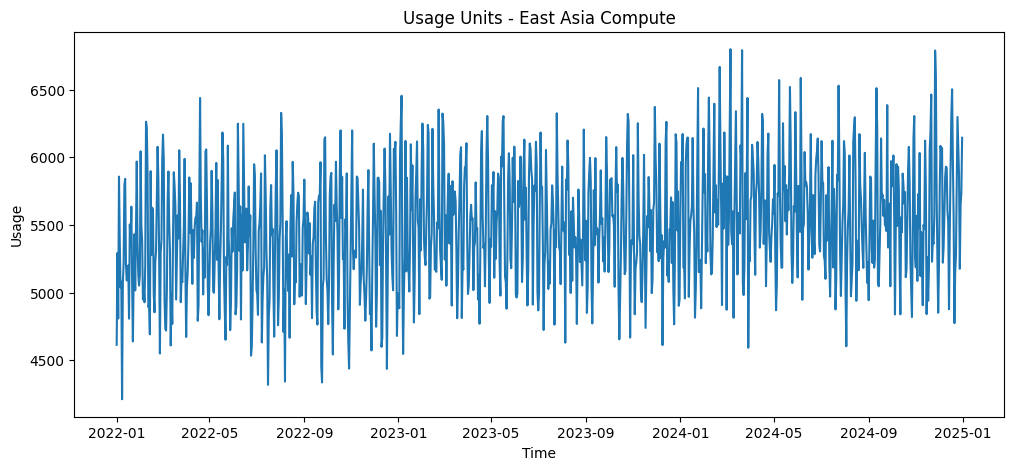

In [13]:
plt.figure(figsize=(12,5))
plt.plot(sample["timestamp"], series)
plt.title("Usage Units - East Asia Compute")
plt.xlabel("Time")
plt.ylabel("Usage")
plt.show()

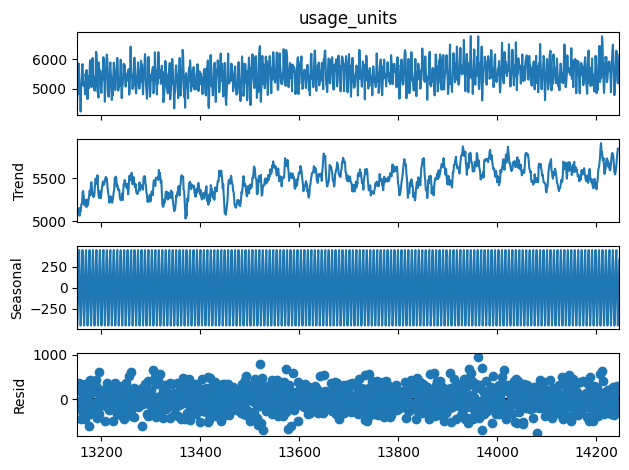

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(series, model='additive', period=7)

decomposition.plot()
plt.show()

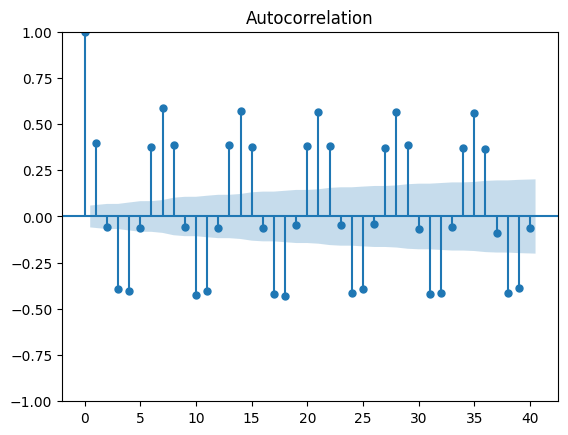

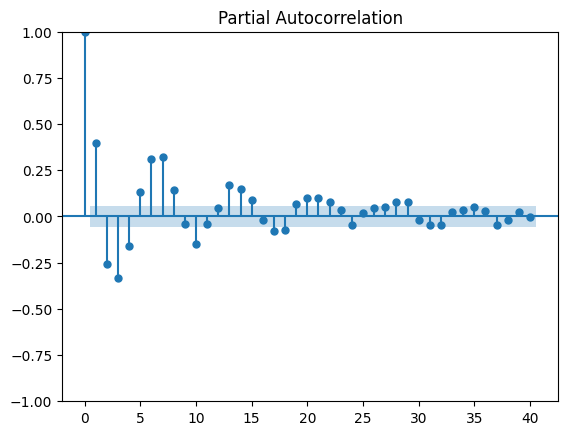

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(series.dropna(), lags=40)
plt.show()

plot_pacf(series.dropna(), lags=40)
plt.show()

##Statistical Tests

In [13]:
from statsmodels.tsa.stattools import adfuller

results = []

for (region, service), group in df.groupby(["region","service_type"]):

    series = group.sort_values("timestamp")["usage_units"].dropna()

    adf_stat, p_value, _, _, _, _ = adfuller(series)

    results.append({
        "region": region,
        "service_type": service,
        "adf_stat": adf_stat,
        "p_value": p_value,
        "stationary": p_value < 0.05
    })

adf_results = pd.DataFrame(results)
adf_results

,region,service_type,adf_stat,p_value,stationary
0,Australia East,Compute,-2.263997,0.183843,False
1,Australia East,Storage,-2.311681,0.168228,False
2,Australia Southeast,Compute,-0.941597,0.773966,False
3,Australia Southeast,Storage,-0.973297,0.762879,False
4,Brazil South,Compute,-2.541301,0.105746,False
...,...,...,...,...,...
59,West US,Storage,-2.450329,0.128032,False
60,West US 2,Compute,-2.837674,0.053090,False
61,West US 2,Storage,-2.548030,0.104221,False
62,West US 3,Compute,-2.028040,0.274416,False


In [14]:
adf_results['stationary'].value_counts()

stationary
False    58
True      6
Name: count, dtype: int64

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

seasonal_strength = []

for (region, service), group in df.groupby(["region","service_type"]):

    series = group.sort_values("timestamp")["usage_units"].dropna()

    decomposition = seasonal_decompose(series, model='additive', period=7)

    seasonal_var = np.var(decomposition.seasonal)
    total_var = np.var(series)

    strength = seasonal_var / total_var

    seasonal_strength.append({
        "region": region,
        "service_type": service,
        "seasonal_strength": strength
    })

season_df = pd.DataFrame(seasonal_strength)

In [19]:
season_df

,region,service_type,seasonal_strength
0,Australia East,Compute,0.499127
1,Australia East,Storage,0.490440
2,Australia Southeast,Compute,0.375700
3,Australia Southeast,Storage,0.389229
4,Brazil South,Compute,0.477526
...,...,...,...
59,West US,Storage,0.508617
60,West US 2,Compute,0.489662
61,West US 2,Storage,0.509010
62,West US 3,Compute,0.447414


In [20]:
auto_results = []

for (region, service), group in df.groupby(["region","service_type"]):

    series = group.sort_values("timestamp")["usage_units"].dropna()

    auto_results.append({
        "region": region,
        "service_type": service,
        "lag1": series.autocorr(lag=1),
        "lag7": series.autocorr(lag=7),
        "lag30": series.autocorr(lag=30)
    })

auto_all = pd.DataFrame(auto_results)

auto_all.describe()

,lag1,lag7,lag30
count,64.000000,64.000000,64.000000
mean,0.490843,0.654861,0.115338
std,0.076159,0.053821,0.124020
min,0.372134,0.557004,-0.071278
25%,0.426638,0.614976,0.010036
50%,0.482271,0.653689,0.086841
75%,0.564142,0.702262,0.217607
max,0.627086,0.759484,0.332274


In [21]:
macro_corr = df.groupby(["region","service_type"])[
    ["usage_units","gdp_growth_rate","it_spending_index","enterprise_demand_index","internet_traffic_growth"]
].corr().reset_index()

macro_corr.head()

,region,service_type,level_2,usage_units,gdp_growth_rate,it_spending_index,enterprise_demand_index,internet_traffic_growth
0,Australia East,Compute,usage_units,1.000000,0.007843,0.291425,0.291401,-0.049119
1,Australia East,Compute,gdp_growth_rate,0.007843,1.000000,-0.259446,-0.259382,0.017484
2,Australia East,Compute,it_spending_index,0.291425,-0.259446,1.000000,0.999953,-0.125445
3,Australia East,Compute,enterprise_demand_index,0.291401,-0.259382,0.999953,1.000000,-0.125416
4,Australia East,Compute,internet_traffic_growth,-0.049119,0.017484,-0.125445,-0.125416,1.000000


In [22]:
df[["usage_units","gdp_growth_rate","it_spending_index","enterprise_demand_index","internet_traffic_growth"]].corr()

,usage_units,gdp_growth_rate,it_spending_index,enterprise_demand_index,internet_traffic_growth
usage_units,1.000000,-0.018909,0.190058,0.193722,-0.026104
gdp_growth_rate,-0.018909,1.000000,-0.259446,-0.210465,0.017484
it_spending_index,0.190058,-0.259446,1.000000,0.811235,-0.125445
enterprise_demand_index,0.193722,-0.210465,0.811235,1.000000,-0.101766
internet_traffic_growth,-0.026104,0.017484,-0.125445,-0.101766,1.000000


#Model Building

In [15]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["region","service_type","timestamp"])
df = df.set_index("timestamp")
# df = df.asfreq("D")

split_date = "2024-01-01"

train = df[df.index < split_date]
test = df[df.index >= split_date]

exog_vars = [
"gdp_growth_rate",
"it_spending_index",
"enterprise_demand_index",
"internet_traffic_growth"
]

results = []
forecast_rows = []
for (region,service), group in df.groupby(["region","service_type"]):

    gtrain = train[(train["region"]==region)&(train["service_type"]==service)]
    gtest = test[(test["region"]==region)&(test["service_type"]==service)]

    y_train = gtrain["usage_units"]
    y_test = gtest["usage_units"]

    X_train_exog = gtrain[exog_vars]
    X_test_exog = gtest[exog_vars]

    model_arima = SARIMAX(
        y_train,
        order=(2,1,2),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit_arima = model_arima.fit(disp=False,maxiter=50)
    pred_arima = fit_arima.forecast(len(y_test))

    model_sarima = SARIMAX(
        y_train,
        order=(2,1,1),
        seasonal_order=(1,1,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit_sarima = model_sarima.fit(disp=False,maxiter=50)
    pred_sarima = fit_sarima.forecast(len(y_test))


    models = {
        "ARIMA":pred_arima,
        "SARIMA":pred_sarima,
    }

    for name,pred in models.items():

        mae = mean_absolute_error(y_test,pred)
        rmse = np.sqrt(mean_squared_error(y_test,pred))
        bias = np.mean(pred - y_test)

        results.append({
            "region":region,
            "service_type":service,
            "model":name,
            "MAE":mae,
            "RMSE":rmse,
            "Bias":bias
        })

        temp = pd.DataFrame({
            "timestamp":gtest.index,
            "region":region,
            "service_type":service,
            "actual":y_test.values,
            "forecast":pred.values,
            "model":name
        })

        forecast_rows.append(temp)

metrics_df = pd.DataFrame(results)
forecast_df = pd.concat(forecast_rows)

In [ ]:
import itertools
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

p = range(0,3)
d = range(0,3)
q = range(0,3)

pdq = list(itertools.product(p,d,q))

arima_rows = []

for (region,service), group in df.groupby(["region","service_type"]):

    y = group["usage_units"]

    best_aic = float("inf")
    best_order = None

    for order in pdq:

        try:
            model = SARIMAX(
                y,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False)

            if result.aic < best_aic:
                best_aic = result.aic
                best_order = order

        except:
            continue

    arima_rows.append({
        "region":region,
        "service_type":service,
        "p":best_order[0],
        "d":best_order[1],
        "q":best_order[2]
    })

arima_params = pd.DataFrame(arima_rows)

In [79]:
import itertools
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

p = range(0,3)
d = range(0,3)
q = range(0,3)

for (region,service), group in df.groupby(["region","service_type"]):

    gtrain = train[(train["region"]==region) & (train["service_type"]==service)]
    gtest = test[(test["region"]==region) & (test["service_type"]==service)]

    y_train = gtrain["usage_units"].dropna()
    y_test = gtest["usage_units"].dropna()

    if len(y_train) == 0 or len(y_test) == 0:
        print(region, service, "Skipped (no train/test data)")
        continue

    best_score = float("inf")
    best_order = None

    for i in p:
        for j in d:
            for k in q:

                try:

                    model = ARIMA(y_train, order=(i,j,k))
                    fit = model.fit()

                    pred = fit.forecast(steps=len(y_test))

                    rmse = np.sqrt(mean_squared_error(y_test.values, pred.values))

                    if rmse < best_score:
                        best_score = rmse
                        best_order = (i,j,k)

                except:Australia East Co
                    continue

    print(region, service, best_order)

Australia East Compute (2, 0, 2)
Australia East Storage (2, 0, 2)
Australia Southeast Compute (1, 2, 2)
Australia Southeast Storage (1, 2, 2)
Brazil South Compute (2, 0, 2)
Brazil South Storage (2, 0, 2)
Canada Central Compute (2, 2, 1)
Canada Central Storage (1, 2, 2)
Canada East Compute (2, 0, 2)
Canada East Storage (2, 0, 2)
Central US Compute (1, 2, 2)
Central US Storage (1, 2, 2)
East Asia Compute (2, 0, 2)
East Asia Storage (2, 0, 2)
East US Compute (2, 1, 2)
East US Storage (1, 2, 2)
East US 2 Compute (2, 0, 2)
East US 2 Storage (2, 0, 2)
France Central Compute (2, 0, 2)
France Central Storage (2, 0, 2)
Germany West Central Compute (2, 0, 2)
Germany West Central Storage (2, 0, 2)
India Central Compute (1, 2, 2)
India Central Storage (2, 0, 2)
India South Compute (0, 2, 2)
India South Storage (1, 2, 2)
India West Compute (2, 0, 2)
India West Storage (2, 0, 2)
Japan East Compute (2, 0, 2)
Japan East Storage (1, 2, 2)
Japan West Compute (0, 2, 2)
Japan West Storage (1, 2, 2)
Korea 

In [ ]:
import itertools
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

p = range(0,3)
d = range(0,3)
q = range(0,3)

P = range(0,2)
D = range(0,2)
Q = range(0,2)

for (region,service), group in df.groupby(["region","service_type"]):

    gtrain = train[(train["region"]==region) & (train["service_type"]==service)]
    gtest = test[(test["region"]==region) & (test["service_type"]==service)]

    y_train = gtrain["usage_units"].dropna()
    y_test = gtest["usage_units"].dropna()

    if len(y_train) == 0 or len(y_test) == 0:
        print(region, service, "Skipped (no train/test data)")
        continue

    best_score = float("inf")
    best_order = None
    best_seasonal = None

    for i in p:
        for j in d:
            for k in q:
                for I in P:
                    for J in D:
                        for K in Q:

                            try:

                                model = SARIMAX(
                                    y_train,
                                    order=(i,j,k),
                                    seasonal_order=(I,J,K,7),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                )

                                fit = model.fit(disp=False)

                                pred = fit.forecast(steps=len(y_test))

                                rmse = np.sqrt(mean_squared_error(y_test.values, pred.values))

                                if rmse < best_score:
                                    best_score = rmse
                                    best_order = (i,j,k)
                                    best_seasonal = (I,J,K,7)

                            except:
                                continue
    print(region, service, best_order, best_seasonal)

In [16]:
from xgboost import XGBRegressor
import pandas as pd

df_ml = pd.get_dummies(df, columns=["region","service_type"], drop_first=True)

train_ml = df_ml[df_ml.index < split_date]
test_ml = df_ml[df_ml.index >= split_date]

features = [
"lag_1","lag_7","lag_30",
"rolling_mean_7","rolling_std_7",
"month","weekday","quarter",
"gdp_growth_rate","it_spending_index",
"enterprise_demand_index","internet_traffic_growth"
]

region_service_cols = [c for c in df_ml.columns if ("region_" in c) or ("service_type_" in c)]

features = features + region_service_cols

X_train = train_ml[features]
y_train = train_ml["usage_units"]

X_test = test_ml[features]
y_test = test_ml["usage_units"]

model_xgb = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.1
)

model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

temp_xgb = pd.DataFrame({
    "timestamp": test.index,
    "region": test["region"],
    "service_type": test["service_type"],
    "actual": y_test.values,
    "forecast": pred_xgb,
    "model": "XGBoost"
})

forecast_rows.append(temp_xgb)

forecast_df = pd.concat(forecast_rows)

In [22]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

param_grid = {
    "n_estimators": [200,300,400,500],
    "max_depth": [4,6,10],
    "learning_rate": [0.03,0.05,0.1,0.2]
}

xgb = XGBRegressor(n_jobs=-1)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500}


In [17]:
forecast_df

,timestamp,region,service_type,actual,forecast,model
0,2024-01-01,Australia East,Compute,4547.78,4689.189111,ARIMA
1,2024-01-02,Australia East,Compute,5007.51,4801.139231,ARIMA
2,2024-01-03,Australia East,Compute,5425.50,4825.882874,ARIMA
3,2024-01-04,Australia East,Compute,4680.21,4786.064048,ARIMA
4,2024-01-05,Australia East,Compute,4402.78,4732.635291,ARIMA
...,...,...,...,...,...,...
2024-12-27 00:00:00,2024-12-27,West US 3,Storage,3796.51,3776.572266,XGBoost
2024-12-28 00:00:00,2024-12-28,West US 3,Storage,3544.53,3602.932617,XGBoost
2024-12-29 00:00:00,2024-12-29,West US 3,Storage,3903.46,3793.719971,XGBoost
2024-12-30 00:00:00,2024-12-30,West US 3,Storage,4125.10,3966.198975,XGBoost


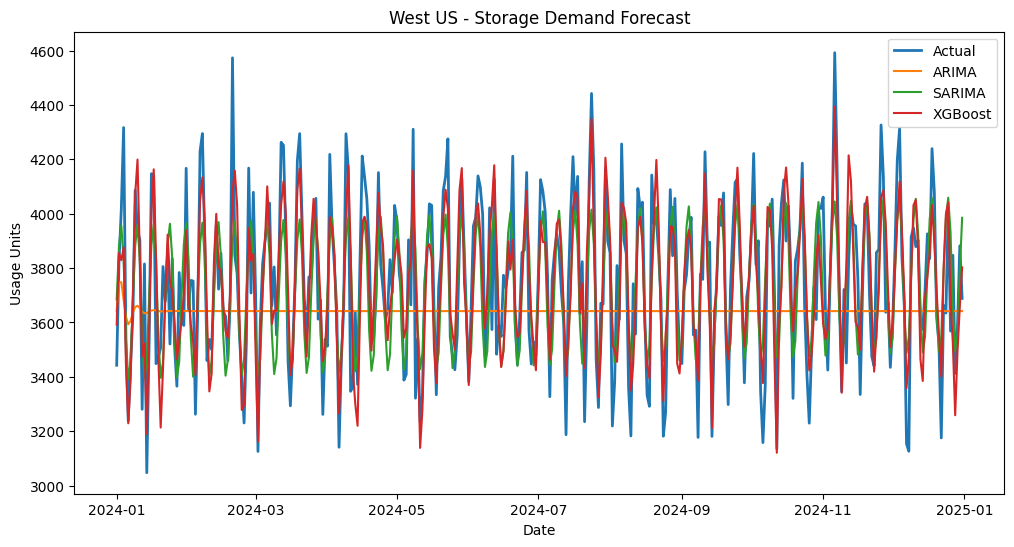

In [21]:
import matplotlib.pyplot as plt

region = "West US"
service = "Storage"

temp = forecast_df[
    (forecast_df["region"] == region) &
    (forecast_df["service_type"] == service)
]

pivot_df = temp.pivot(index="timestamp", columns="model", values="forecast")

pivot_df["Actual"] = temp.drop_duplicates("timestamp").set_index("timestamp")["actual"]

plt.figure(figsize=(12,6))

plt.plot(pivot_df.index, pivot_df["Actual"], label="Actual", linewidth=2)

for col in pivot_df.columns:
    if col != "Actual":
        plt.plot(pivot_df.index, pivot_df[col], label=col)

plt.title(f"{region} - {service} Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Usage Units")
plt.legend()
plt.show()